#**Customer Churn Analysis and Prediction**

The project aims to analyze customer churn in a telecommunications company and develop predictive models to identify at-risk customers.The ultimate goal is to provide actionable insights and recommendations to reduce churn and improve
customer retention.


---



#**Tasks 1: Data Cleaning and Preprocessing**

##Upload the CSV file

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco_Customer_Churn_Dataset .csv to Telco_Customer_Churn_Dataset .csv


##Load the Dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")

##Explore the Dataset

In [ ]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##Find Hidden Missing Values

In [ ]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

##Convert TotalCharges to Numeric

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

##Handle Missing Values

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
print(df["TotalCharges"].isnull().sum())

0


##Remove Unnecessary Column

In [ ]:
df.drop("customerID", axis=1, inplace=True)

##Identify Categorical Columns

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print(categorical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


##Convert Binary Categories

In [ ]:
binary_map = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

for col in df.columns:
    if df[col].dtype == "object":
        unique_vals = df[col].unique()
        if len(unique_vals) == 2:
            df[col] = df[col].map(binary_map)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


##One-Hot Encode Multi-Class Columns

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaymentMethod"
    ],
    drop_first=True
)

##Verify All Columns Are Numeric

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

##Save Cleaned Dataset

In [ ]:
df.to_csv(
    "Telco_Customer_Churn_Cleaned.csv",
    index=False
)

#**Tasks 2: Exploratory Data Analysis (EDA)**

##Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Overall Churn Rate

**What is churn rate?**
% of customers who left the company

In [ ]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)

Churn
0    5174
1    1869
Name: count, dtype: int64


**Convert to percentage**

In [ ]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


**📊 Visualization (Pie Chart)**

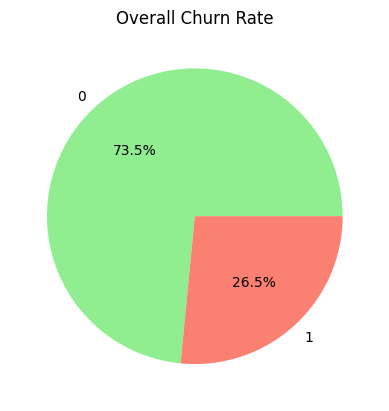

In [ ]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["lightgreen", "salmon"]
)
plt.title("Overall Churn Rate")
plt.ylabel("")
plt.show()

##Customer Distribution by Demographics

**📌 Gender vs Churn**

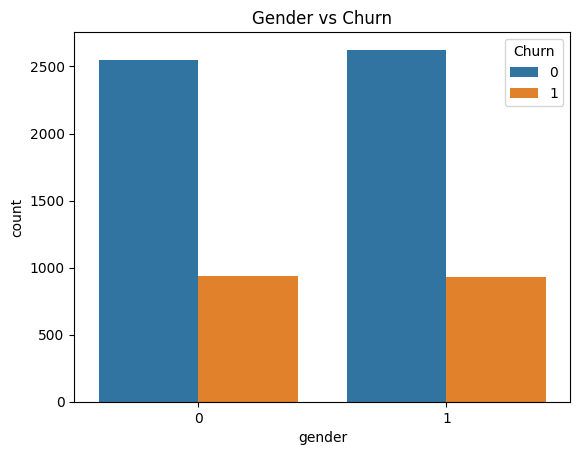

In [ ]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Gender vs Churn")
plt.show()

**📌 Senior Citizen vs Churn**

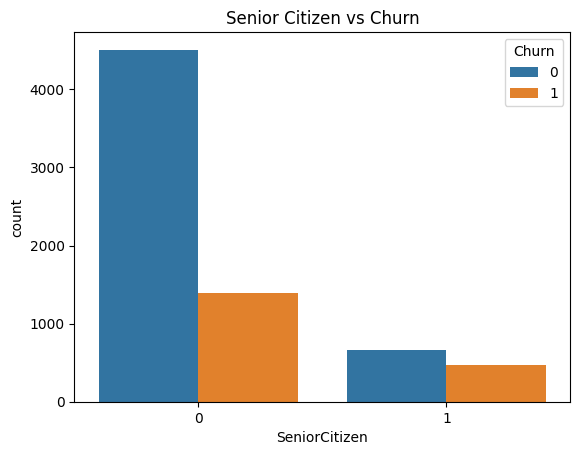

In [ ]:
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Senior Citizen vs Churn")
plt.show()

📌 **Partner vs Churn**

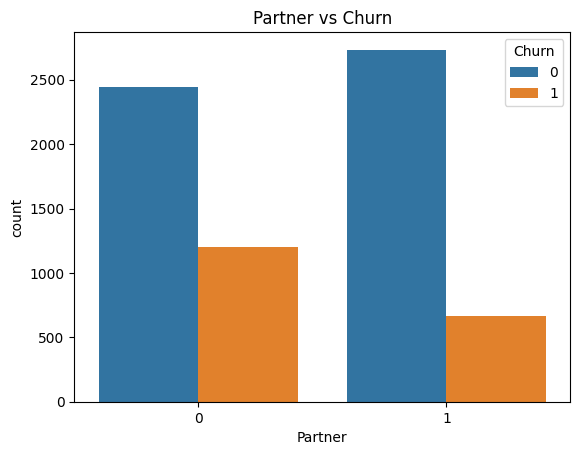

In [ ]:
sns.countplot(data=df, x="Partner", hue="Churn")
plt.title("Partner vs Churn")
plt.show()

📌 **Dependents vs Churn**

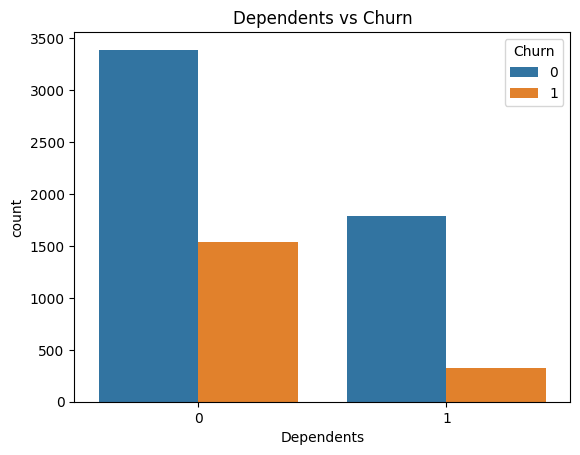

In [ ]:
sns.countplot(data=df, x="Dependents", hue="Churn")
plt.title("Dependents vs Churn")
plt.show()

##Tenure Distribution

**Histogram**

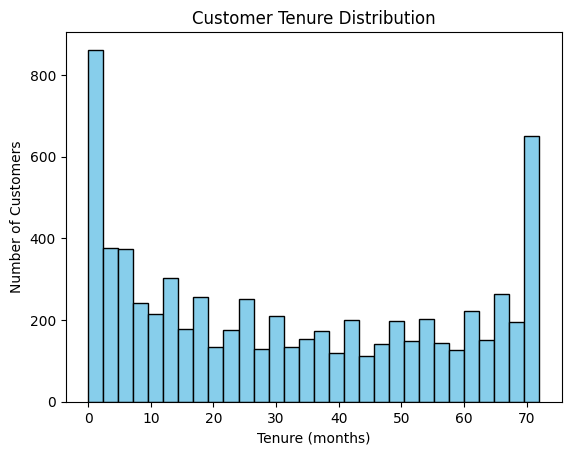

In [ ]:
plt.hist(df["tenure"], bins=30, color="skyblue", edgecolor="black")
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.show()

Insight:
1.   Many customers are new (low tenure)
2.   Long-term customers are fewer but more stable

##Tenure vs Churn

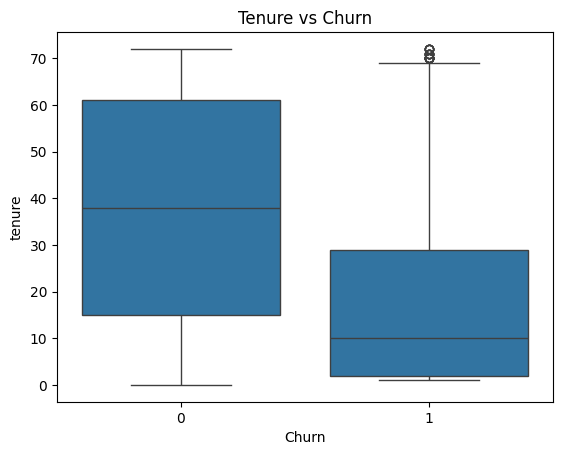

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

Insight:
1.   Customers who churn usually have LOW tenure
2.   Loyal customers stay longer

##Contract Type vs Churn

In [ ]:
df["Contract"] = (
    df["Contract_One year"] * 1 +
    df["Contract_Two year"] * 2
)

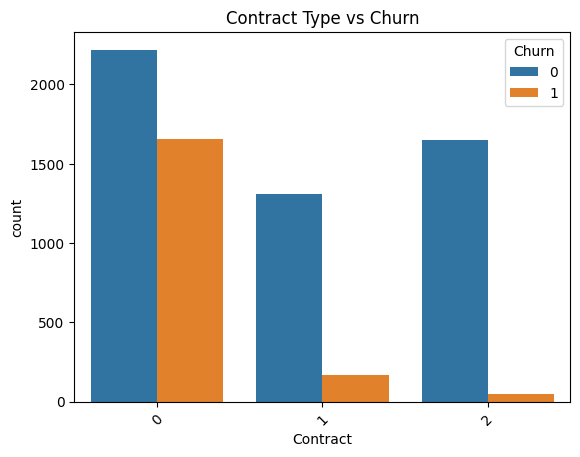

In [ ]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=45)
plt.show()

Insight:
1.   Month-to-month contracts → HIGH churn
2.   1-year / 2-year contracts → LOW churn



##Payment Method vs Churn

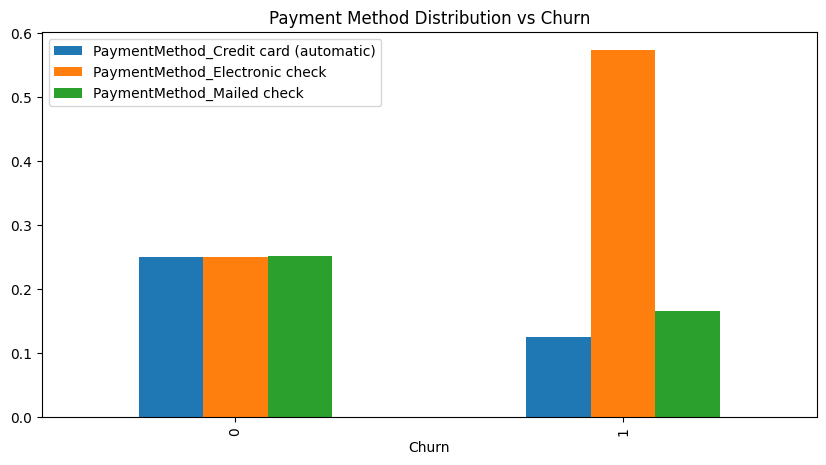

In [ ]:
df[[
    "PaymentMethod_Credit card (automatic)",
    "PaymentMethod_Electronic check",
    "PaymentMethod_Mailed check",
    "Churn"
]].groupby("Churn").mean().plot(kind="bar", figsize=(10,5))
plt.title("Payment Method Distribution vs Churn")
plt.show()

Insight:


1.   Electronic check users → higher churn
2.   Automatic payments → lower churn




**Churn rate by Contract type (percentage)**

In [ ]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print(contract_churn)

Churn             0          1
Contract                      
0         57.290323  42.709677
1         88.730482  11.269518
2         97.168142   2.831858


**Bar chart**

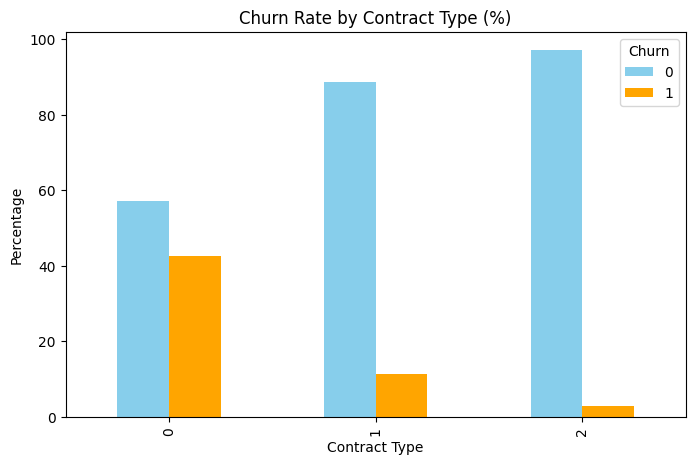

In [ ]:
contract_churn.plot(kind="bar", figsize=(8,5), color=["skyblue", "orange"])

plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Percentage")
plt.xlabel("Contract Type")
plt.legend(title="Churn")
plt.show()

#**Tasks 3: Customer Segmentation**

##Tenure Groups

In [ ]:
def tenure_group(x):
    if x <= 12:
        return "New (0-1 yr)"
    elif x <= 24:
        return "Young (1-2 yrs)"
    elif x <= 48:
        return "Mid (2-4 yrs)"
    else:
        return "Long-term (4+ yrs)"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

##Monthly Charges Groups

In [ ]:
def charge_group(x):
    if x < 35:
        return "Low"
    elif x < 70:
        return "Medium"
    else:
        return "High"

df["ChargeGroup"] = df["MonthlyCharges"].apply(charge_group)

##Contract Type Column

In [ ]:
def contract_type(row):
    if row["Contract_Two year"] == 1:
        return "Two Year"
    elif row["Contract_One year"] == 1:
        return "One Year"
    else:
        return "Month-to-Month"

df["ContractType"] = df.apply(contract_type, axis=1)

##Churn Rate by Segment

**Churn by Tenure Group**

TenureGroup
Long-term (4+ yrs)     9.513176
Mid (2-4 yrs)         20.388959
New (0-1 yr)          47.438243
Young (1-2 yrs)       28.710938
Name: Churn, dtype: float64


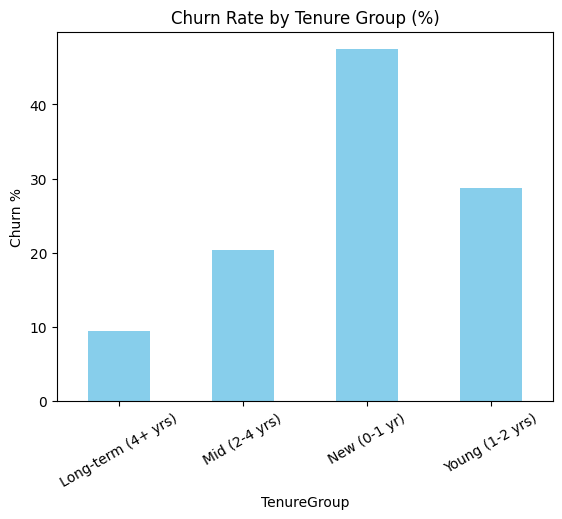

In [ ]:
tenure_churn = df.groupby("TenureGroup")["Churn"].mean() * 100
print(tenure_churn)

tenure_churn.plot(kind="bar", color="skyblue")
plt.title("Churn Rate by Tenure Group (%)")
plt.ylabel("Churn %")
plt.xticks(rotation=30)
plt.show()

**Churn by Contract Type**

ContractType
Month-to-Month    42.709677
One Year          11.269518
Two Year           2.831858
Name: Churn, dtype: float64


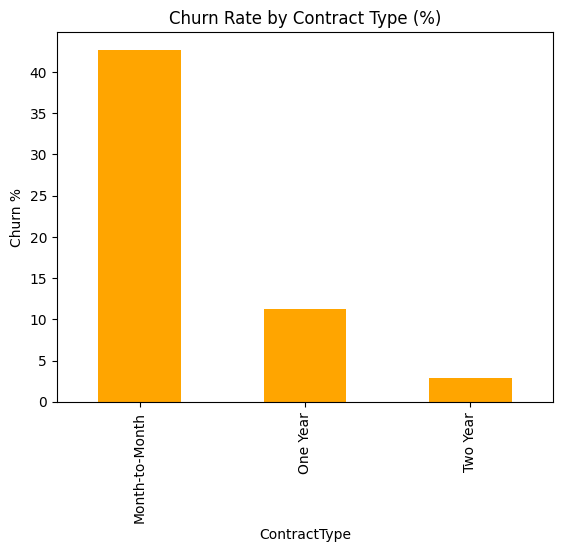

In [ ]:
contract_churn = df.groupby("ContractType")["Churn"].mean() * 100
print(contract_churn)

contract_churn.plot(kind="bar", color="orange")
plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Churn %")
plt.show()

**Churn by Charge Group**

ChargeGroup
High      35.477583
Low       10.860774
Medium    23.649041
Name: Churn, dtype: float64


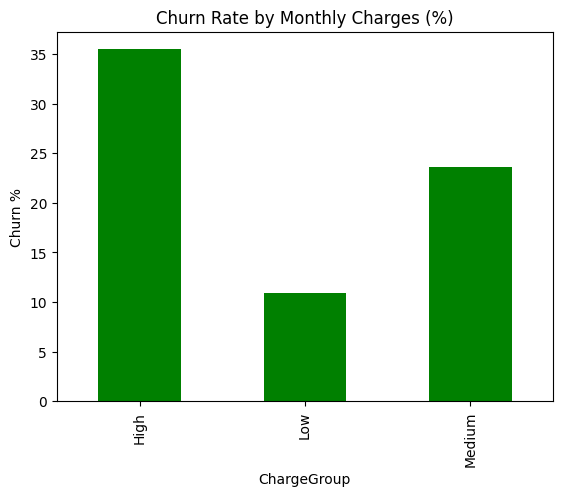

In [ ]:
charge_churn = df.groupby("ChargeGroup")["Churn"].mean() * 100
print(charge_churn)

charge_churn.plot(kind="bar", color="green")
plt.title("Churn Rate by Monthly Charges (%)")
plt.ylabel("Churn %")
plt.show()

##Combine segmentation

In [ ]:
df.groupby(["TenureGroup", "ContractType"])["Churn"].mean() * 100

TenureGroup         ContractType  
Long-term (4+ yrs)  Month-to-Month    26.023392
                    One Year          12.933754
                    Two Year           3.325416
Mid (2-4 yrs)       Month-to-Month    32.917706
                    One Year          10.617761
                    Two Year           2.189781
New (0-1 yr)        Month-to-Month    51.354062
                    One Year          10.483871
                    Two Year           0.000000
Young (1-2 yrs)     Month-to-Month    37.720488
                    One Year           8.121827
                    Two Year           0.000000
Name: Churn, dtype: float64

#**Tasks 4: Churn Prediction Model**

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

##Prepare Data

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

##Check Data Issues

In [ ]:
print(X.shape)
print(y.value_counts())
print(X.dtypes)

(7043, 34)
Churn
0    5174
1    1869
Name: count, dtype: int64
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSu

##Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Feature Scaling

In [ ]:
X_train.select_dtypes(include="object").columns

Index(['TenureGroup', 'ChargeGroup', 'ContractType'], dtype='object')

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Train Logistic Regression Model

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

##Make Predictions

In [ ]:
y_pred = model.predict(X_test)

##Evaluate Model

**Accuracy**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8133427963094393


**Confusion Matrix**

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[938  98]
 [165 208]]


**Full Report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409



##Confusion Matrix Visualization

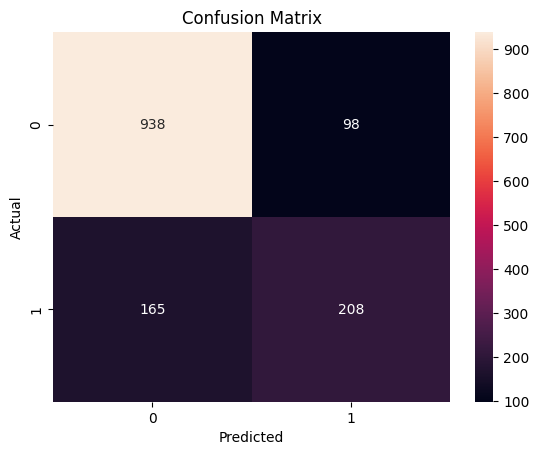

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##ROC-AUC

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, y_prob))

0.8603297380107031


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8133427963094393
ROC-AUC: 0.8603297380107031


#**Tasks 5: Customer Retention Strategies**

#Identify Key Factors Influencing Churn

**Churn by Contract Type**

In [ ]:
df.groupby("ContractType")["Churn"].mean() * 100

,Churn
ContractType,
Month-to-Month,42.709677
One Year,11.269518
Two Year,2.831858


**Churn by Tenure**

In [ ]:
df.groupby("TenureGroup")["Churn"].mean() * 100

,Churn
TenureGroup,
Long-term (4+ yrs),9.513176
Mid (2-4 yrs),20.388959
New (0-1 yr),47.438243
Young (1-2 yrs),28.710938


**Churn by Charges**

In [ ]:
df.groupby("ChargeGroup")["Churn"].mean() * 100

,Churn
ChargeGroup,
High,35.477583
Low,10.860774
Medium,23.649041


##Identify High-Value Customers at Risk

💎 **High-value customers**

In [ ]:
high_value = df[
    (df["MonthlyCharges"] > df["MonthlyCharges"].median()) &
    (df["tenure"] > 24) &
    (df["Churn"] == 0)
]

**⚠️ At-risk high-value customers**

In [ ]:
at_risk = df[
    (df["MonthlyCharges"] > df["MonthlyCharges"].median()) &
    (df["tenure"] <= 12) &
    (df["Churn"] == 1)
]

##Customer Lifetime Value (LTV)

💰 LTV Formula:
**LTV = MonthlyCharges × tenure**

In [ ]:
df["LTV"] = df["MonthlyCharges"] * df["tenure"]

**Average LTV by churn**

In [ ]:
df.groupby("Churn")["LTV"].mean()

,LTV
Churn,
0,2549.770883
1,1531.608828


**High-value customers**

In [ ]:
df[df["LTV"] > df["LTV"].quantile(0.75)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract,TenureGroup,ChargeGroup,ContractType,LTV
12,1,0,1,0,58,1,0,100.35,5681.10,0,...,True,False,True,False,False,1,Long-term (4+ yrs),High,One Year,5820.30
13,1,0,0,0,49,1,1,103.70,5036.30,1,...,False,False,False,False,False,0,Long-term (4+ yrs),High,Month-to-Month,5081.30
15,0,0,1,1,69,1,0,113.25,7895.15,0,...,False,True,True,False,False,2,Long-term (4+ yrs),High,Two Year,7814.25
17,1,0,0,1,71,1,0,106.70,7382.25,0,...,False,True,False,False,False,2,Long-term (4+ yrs),High,Two Year,7575.70
26,1,0,1,1,47,1,1,99.35,4749.15,1,...,False,False,False,True,False,0,Mid (2-4 yrs),High,Month-to-Month,4669.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,0,1,1,0,63,1,1,103.50,6479.40,0,...,False,False,False,True,False,0,Long-term (4+ yrs),High,Month-to-Month,6520.50
7028,0,0,1,0,68,1,0,64.10,4326.25,0,...,False,True,False,False,False,2,Long-term (4+ yrs),Medium,Two Year,4358.80
7034,0,0,0,0,67,1,1,102.95,6886.25,1,...,False,False,True,False,False,0,Long-term (4+ yrs),High,Month-to-Month,6897.65
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,True,False,True,False,False,1,Long-term (4+ yrs),High,One Year,7430.40


##Retention Strategies

###**💡 FINAL RETENTION STRATEGIES**
1️⃣ Focus on Month-to-Month Customers

*   Highest churn group
*   Offer discounts for yearly plans
*   Push contract upgrades

2️⃣ Early Tenure Retention (First 6–12 months)

*   Most customers churn early
*   Improve onboarding experience
*   Give welcome offers + support calls

3️⃣ Control High Monthly Charges

*   High pricing increases churn risk
*   Introduce flexible bundles or discounts
*   Personalized pricing offers

4️⃣ Target High-Value At-Risk Customers

*   Identify customers with high LTV + high churn risk
*   Offer VIP retention plans
*   Provide loyalty rewards

5️⃣ Improve Payment Experience

*   Promote automatic payment methods
*   Reduce friction in billing system

#**Tasks 6: Visualizations**

##Import Visualization Libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 📦 Box Plots

**Monthly Charges vs Churn**

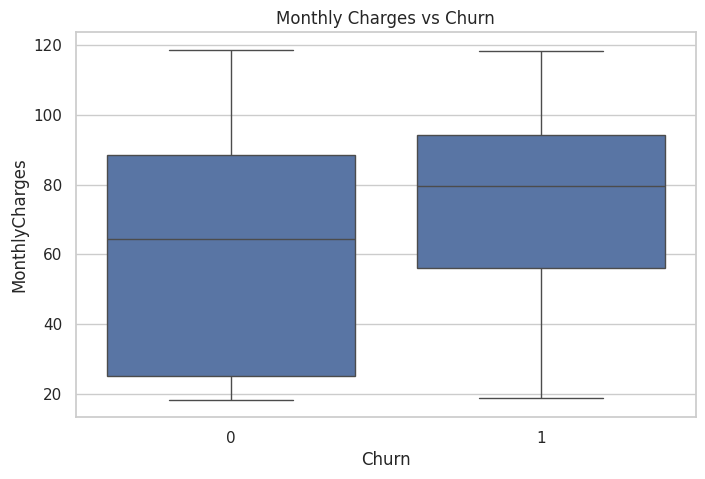

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Tenure vs Churn**

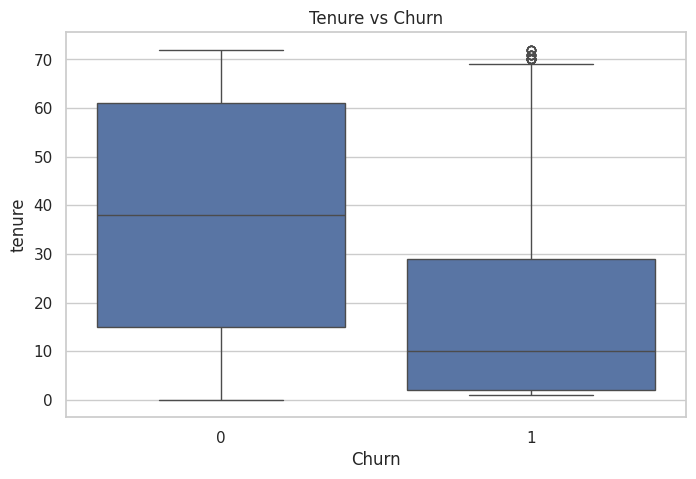

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

##🎻 Violin Plots

**Monthly Charges distribution**

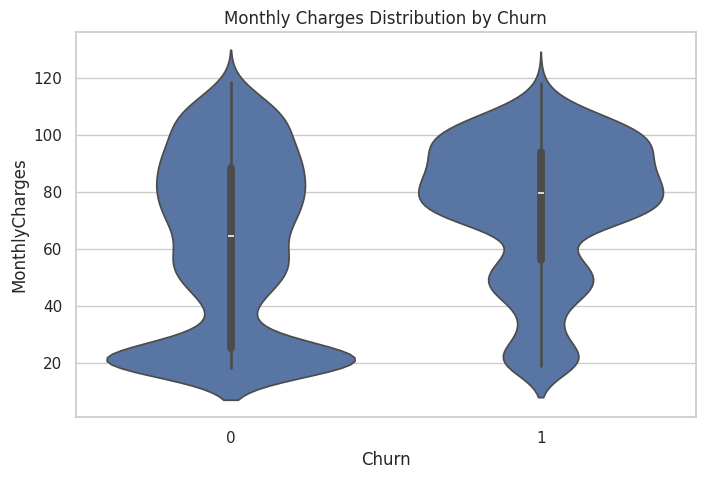

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

**Tenure distribution**

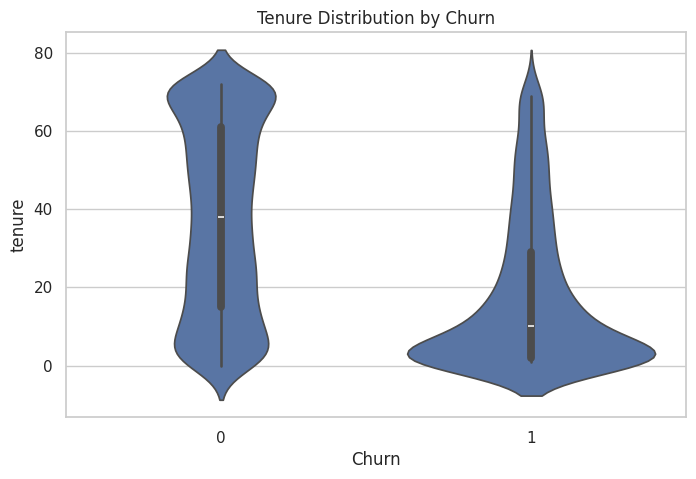

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Churn", y="tenure", data=df)
plt.title("Tenure Distribution by Churn")
plt.show()

##Pair Plot

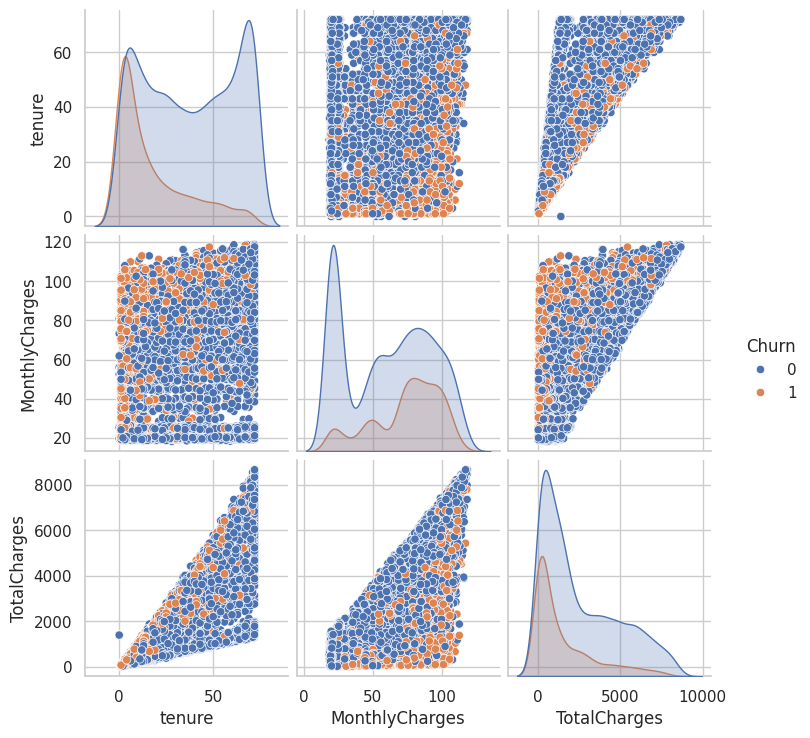

In [ ]:
sns.pairplot(df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]], hue="Churn")
plt.show()

##Correlation Heatmap

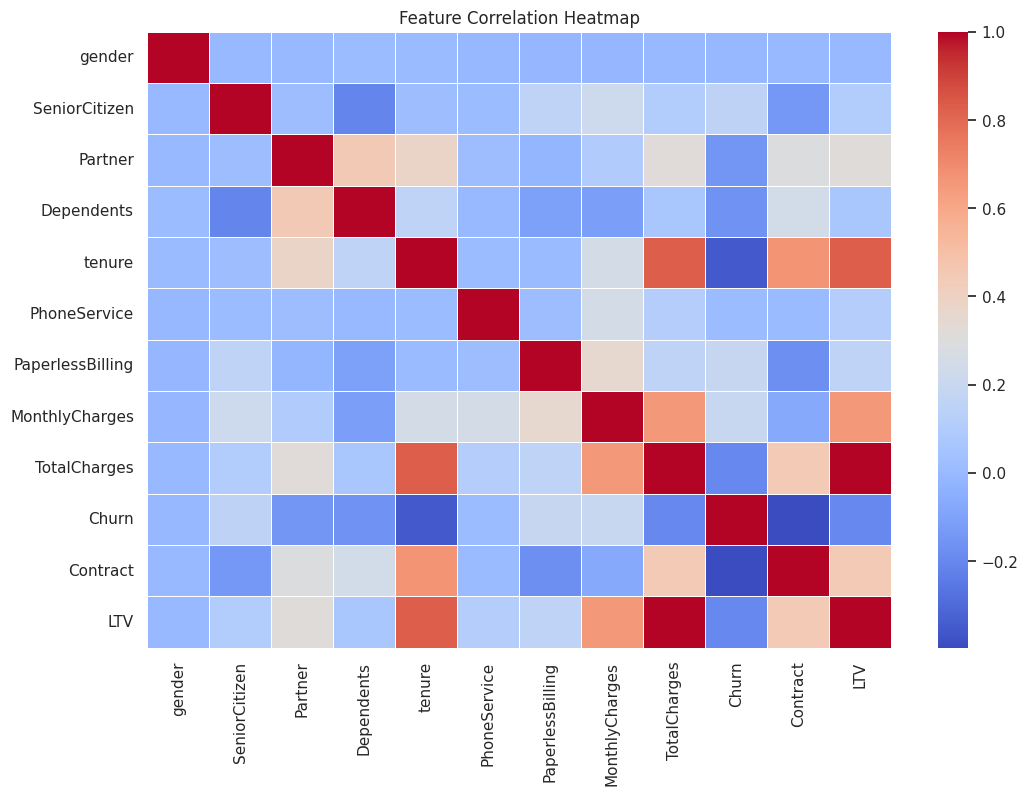

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

##Churn Rate Bar Plots

**Contract type vs churn**

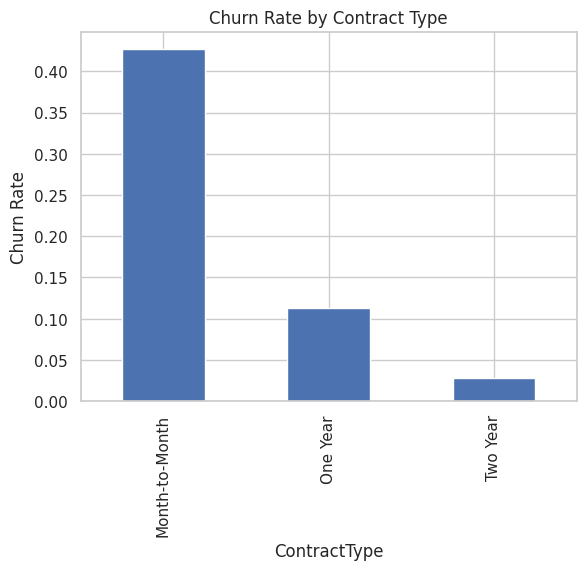

In [ ]:
df.groupby("ContractType")["Churn"].mean().plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()